Part 1 — Install & Load Data

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

file_path = "/content/YWLugDURcz3uGdBgCUtxyV9w8fg1gOYt.xlsx"

df = pd.read_excel(file_path)
print("File loaded successfully ✅")
print("Rows, Columns:", df.shape)

df.head()
df.info()
print("\nMissing values:\n", df.isnull().sum())

File loaded successfully ✅
Rows, Columns: (9999, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           9999 non-null   object        
 1   is_canceled                     9999 non-null   int64         
 2   lead_time                       9999 non-null   int64         
 3   arrival_date_year               9999 non-null   int64         
 4   arrival_date_month              9999 non-null   object        
 5   arrival_date_week_number        9999 non-null   int64         
 6   arrival_date_day_of_month       9999 non-null   int64         
 7   stays_in_weekend_nights         9999 non-null   int64         
 8   stays_in_week_nights            9999 non-null   int64         
 9   adults                          9999 non-null   int64         
 10  children           

Part 2 — Data Cleaning


# Drop duplicates


In [ ]:
before = len(df)
df.drop_duplicates(inplace=True)
print("dtypes:\n", df.dtypes)
print(f"Removed {before - len(df)} duplicates | Remaining: {len(df)}")

dtypes:
 hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_ro

# Missing values

In [ ]:
print("\nMissing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(df['agent'].median(), inplace=True)
df['company'].fillna(0, inplace=True)
print("\nMissing values after fix:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("✅ No missing values!" if df.isnull().sum().sum() == 0 else "")



Missing values before:
country       4
agent       336
company    6370
dtype: int64

Missing values after fix:
Series([], dtype: int64)
✅ No missing values!


# Outlier treatment on adr using IQR


In [ ]:
Q1  = df['adr'].quantile(0.25)
Q3  = df['adr'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['adr'] = df['adr'].clip(lower, upper)
print(f"adr clipped to [{lower:.1f} - {upper:.1f}]")
for col in ['lead_time', 'adults', 'children', 'stays_in_week_nights']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    print(f"{col} clipped.")

adr clipped to [-29.1 - 269.4]
lead_time clipped.
adults clipped.
children clipped.
stays_in_week_nights clipped.


In [ ]:
print("Duplicates before final cleaning:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after final cleaning:", df.duplicated().sum())
print("Final shape:", df.shape)

Duplicates before final cleaning: 44
Duplicates after final cleaning: 0
Final shape: (6437, 32)


In [ ]:
# لو total_nights مش موجود نعمله الأول
if "total_nights" not in df.columns:
    df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

print("Before final quality fixes:")
print("ADR = 0:", (df["adr"] == 0).sum())
print("total_nights = 0:", (df["total_nights"] == 0).sum())
print("meal Undefined:", (df["meal"] == "Undefined").sum())
print("reservation_status values:")
print(df["reservation_status"].value_counts())

df = df[df["adr"] > 0].copy()

df = df[df["total_nights"] > 0].copy()

df["meal"] = df["meal"].replace("Undefined", "Unknown")

df = df.drop_duplicates()

print("\nAfter final quality fixes:")
print("ADR = 0:", (df["adr"] == 0).sum())
print("total_nights = 0:", (df["total_nights"] == 0).sum())
print("meal Undefined:", (df["meal"] == "Undefined").sum())
print("Duplicates:", df.duplicated().sum())
print("Final shape:", df.shape)

Before final quality fixes:
ADR = 0: 26
total_nights = 0: 3
meal Undefined: 39
reservation_status values:
reservation_status
Canceled    6437
Name: count, dtype: int64

After final quality fixes:
ADR = 0: 0
total_nights = 0: 0
meal Undefined: 0
Duplicates: 0
Final shape: (6411, 33)


In [ ]:
print("Final Data Quality Check ✅")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("ADR = 0:", (df["adr"] == 0).sum())
print("total_nights = 0:", (df["total_nights"] == 0).sum())
print("meal Undefined:", (df["meal"] == "Undefined").sum())

Final Data Quality Check ✅
Shape: (6411, 33)
Missing values: 0
Duplicates: 0
ADR = 0: 0
total_nights = 0: 0
meal Undefined: 0


# New derived column

In [ ]:
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print("total_nights column added.")

total_nights column added.


Part 3 — EDA

In [ ]:
print("Summary stats:")
print(df[['adr', 'total_nights', 'lead_time', 'adults']].describe().round(2))

print(f"\nHotel type distribution:\n{df['hotel'].value_counts()}")
print(f"\nTop 10 countries:\n{df['country'].value_counts().head(10)}")
print(f"\nTop booking months:\n{df['arrival_date_month'].value_counts().head(5)}")
print(f"\nMarket segments:\n{df['market_segment'].value_counts()}")
print(f"\nAverage ADR: {df['adr'].mean():.2f}$")
print(f"Average nights: {df['total_nights'].mean():.1f}")

Summary stats:
           adr  total_nights  lead_time  adults
count  6411.00       6411.00    6411.00  6411.0
mean    124.80          4.28     113.89     2.0
std      57.12          2.51      93.22     0.0
min       6.00          1.00       0.00     2.0
25%      83.49          2.00      37.00     2.0
50%     110.33          4.00      88.00     2.0
75%     158.00          6.00     173.00     2.0
max     269.43         23.00     376.00     2.0

Hotel type distribution:
hotel
City Hotel      3279
Resort Hotel    3132
Name: count, dtype: int64

Top 10 countries:
country
PRT    1959
GBR     739
ESP     599
FRA     512
DEU     307
IRL     280
ITA     265
BRA     247
CHE     136
CHN     121
Name: count, dtype: int64

Top booking months:
arrival_date_month
April       1345
May          912
March        887
February     828
January      703
Name: count, dtype: int64

Market segments:
market_segment
Online TA        5189
Direct            418
Offline TA/TO     381
Groups            299
Corporat

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

try:
    pdf.close()
except:
    pass

try:
    plt.show = original_show
except:
    pass

plt.close("all")

pdf_path = "/content/all_charts.pdf"
pdf = PdfPages(pdf_path)

original_show = plt.show

def auto_save_show(*args, **kwargs):
    fig = plt.gcf()

    if len(fig.axes) > 0:
        pdf.savefig(fig, bbox_inches="tight", facecolor=fig.get_facecolor())

    original_show(*args, **kwargs)
    plt.close(fig)

plt.show = auto_save_show

print("Auto PDF saving restarted ✅")

Auto PDF saving restarted ✅


Part 4 — Data Visualization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3150',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#b0b0b0',
    'ytick.color':      '#b0b0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2e3150',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

PALETTE = ['#6c63ff', '#ff6584', '#43b89c', '#ffa94d', '#74c0fc', '#f783ac']
ACCENT  = '#6c63ff'
ACCENT2 = '#ff6584'
BG      = '#0f1117'
CARD    = '#1a1d27'

Pie: Hotel Type Distribution

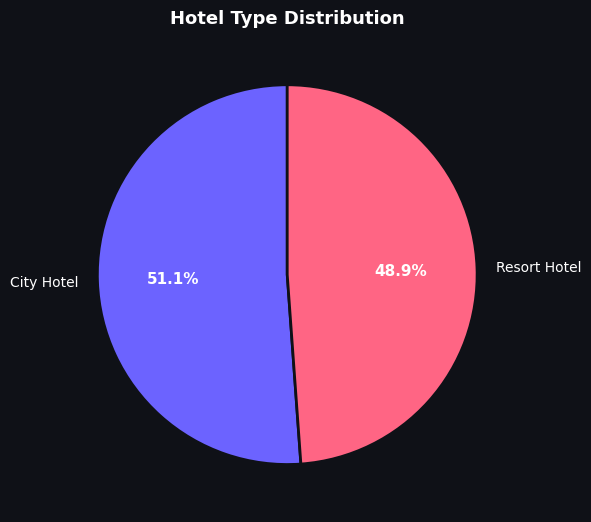

In [ ]:
fig, ax1 = plt.subplots(figsize=(6, 6), facecolor=BG)

hotel_counts = df['hotel'].value_counts()
wedges, texts, autotexts = ax1.pie(
    hotel_counts, labels=hotel_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=[ACCENT, ACCENT2],
    textprops={'color': 'white', 'fontsize': 10},
    wedgeprops={'edgecolor': BG, 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax1.set_title('Hotel Type Distribution', color='white', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

Bar: Bookings by Hotel Type

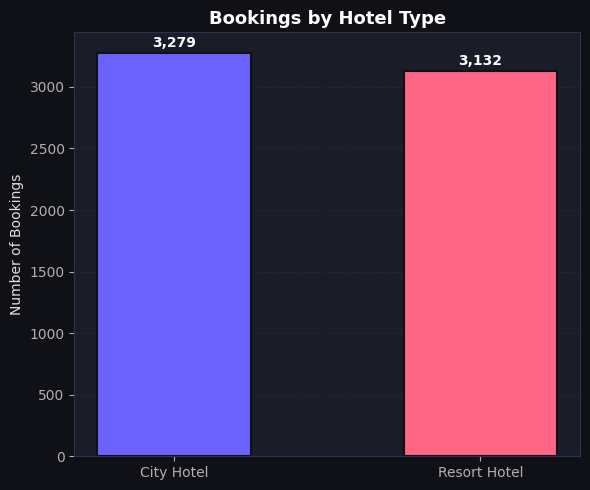

In [ ]:
fig, ax2 = plt.subplots(figsize=(6, 5), facecolor=BG)
ax2.set_facecolor(CARD)

bars = ax2.bar(hotel_counts.index, hotel_counts.values,
               color=[ACCENT, ACCENT2], edgecolor=BG, linewidth=1.5, width=0.5)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{bar.get_height():,}', ha='center', va='bottom',
             color='white', fontsize=10, fontweight='bold')
ax2.set_title('Bookings by Hotel Type', color='white', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of Bookings')
ax2.yaxis.grid(True, alpha=0.4); ax2.set_axisbelow(True)
plt.tight_layout()
plt.show()

Histogram: ADR Distribution

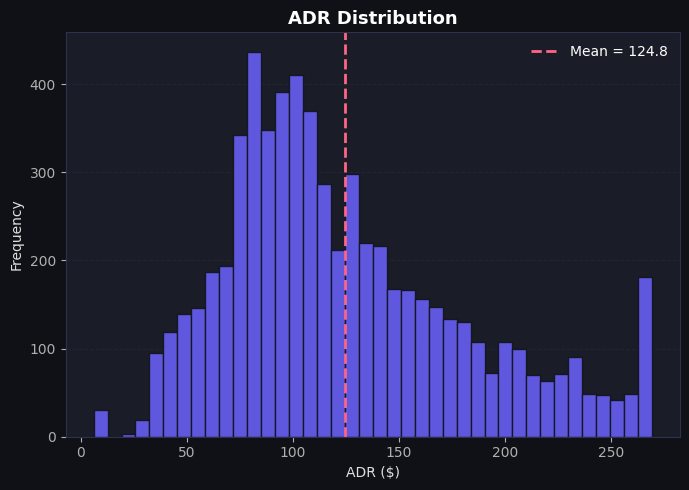

In [ ]:
fig, ax3 = plt.subplots(figsize=(7, 5), facecolor=BG)
ax3.set_facecolor(CARD)

ax3.hist(df['adr'], bins=40, color=ACCENT, edgecolor=BG, alpha=0.85)
ax3.axvline(df['adr'].mean(), color=ACCENT2, linewidth=2, linestyle='--',
            label=f'Mean = {df["adr"].mean():.1f}')
ax3.legend(facecolor=CARD, edgecolor='none', labelcolor='white')
ax3.set_title('ADR Distribution', color='white', fontsize=13, fontweight='bold')
ax3.set_xlabel('ADR ($)'); ax3.set_ylabel('Frequency')
ax3.yaxis.grid(True, alpha=0.4); ax3.set_axisbelow(True)
plt.tight_layout()
plt.show()

Horizontal Bar: Market Segment


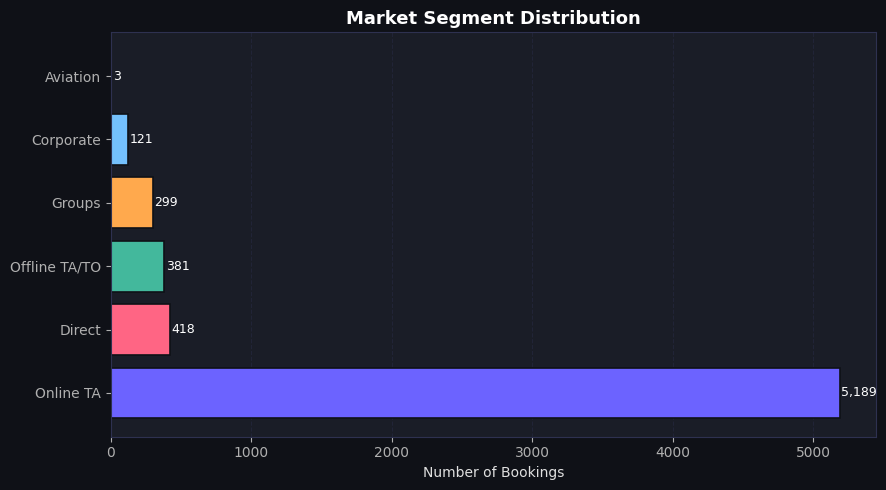

In [ ]:
fig, ax4 = plt.subplots(figsize=(9, 5), facecolor=BG)
ax4.set_facecolor(CARD)

seg_counts = df['market_segment'].value_counts()
colors_seg = [PALETTE[i % len(PALETTE)] for i in range(len(seg_counts))]
bars4 = ax4.barh(seg_counts.index, seg_counts.values,
                  color=colors_seg, edgecolor=BG, linewidth=1.2)
for bar in bars4:
    ax4.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', color='white', fontsize=9)
ax4.set_title('Market Segment Distribution', color='white', fontsize=13, fontweight='bold')
ax4.set_xlabel('Number of Bookings')
ax4.xaxis.grid(True, alpha=0.4); ax4.set_axisbelow(True)
plt.tight_layout()
plt.show()

Boxplot: ADR by Hotel Type

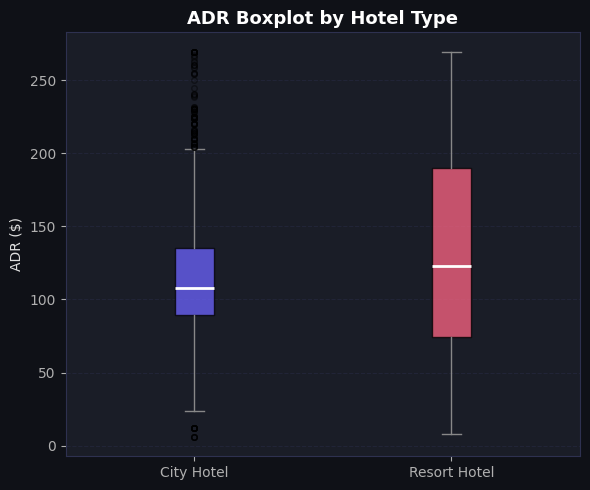

In [ ]:
fig, ax5 = plt.subplots(figsize=(6, 5), facecolor=BG)
ax5.set_facecolor(CARD)

bp = ax5.boxplot([df[df['hotel']=='City Hotel']['adr'],
                  df[df['hotel']=='Resort Hotel']['adr']],
                 patch_artist=True,
                 labels=['City Hotel', 'Resort Hotel'],
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [ACCENT, ACCENT2]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for element in ['whiskers', 'caps']:
    for line in bp[element]: line.set_color('#888888')
for flier in bp['fliers']:
    flier.set(marker='o', color=ACCENT2, alpha=0.4, markersize=4)
ax5.set_title('ADR Boxplot by Hotel Type', color='white', fontsize=13, fontweight='bold')
ax5.set_ylabel('ADR ($)')
ax5.yaxis.grid(True, alpha=0.4); ax5.set_axisbelow(True)
plt.tight_layout()
plt.show()

 Line: Average Monthly ADR

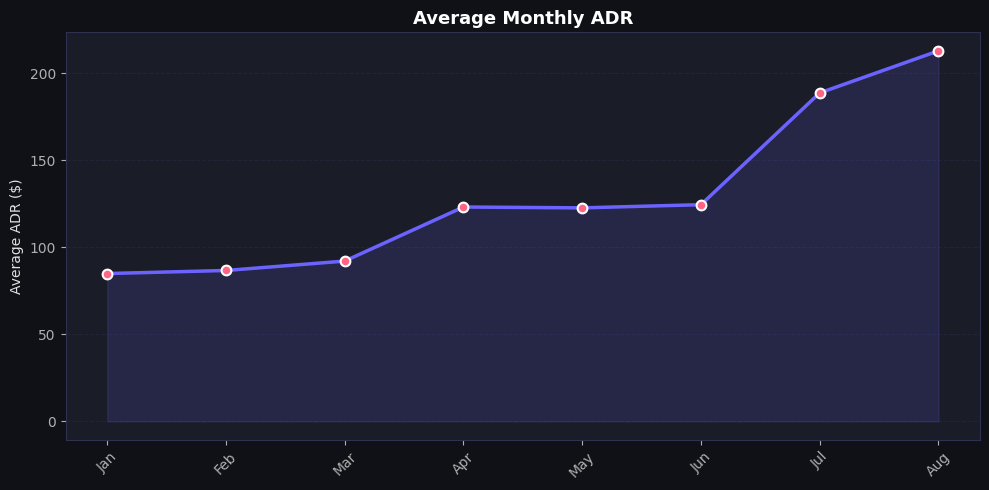

In [ ]:
fig, ax6 = plt.subplots(figsize=(10, 5), facecolor=BG)
ax6.set_facecolor(CARD)

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=month_order, ordered=True)
monthly_adr = df.groupby('arrival_date_month', observed=True)['adr'].mean()

ax6.plot(range(len(monthly_adr)), monthly_adr.values,
         color=ACCENT, linewidth=2.5, marker='o', markersize=7,
         markerfacecolor=ACCENT2, markeredgecolor='white', markeredgewidth=1.5)
ax6.fill_between(range(len(monthly_adr)), monthly_adr.values, alpha=0.15, color=ACCENT)
ax6.set_xticks(range(len(monthly_adr)))
ax6.set_xticklabels([m[:3] for m in monthly_adr.index], rotation=45)
ax6.set_title('Average Monthly ADR', color='white', fontsize=13, fontweight='bold')
ax6.set_ylabel('Average ADR ($)')
ax6.yaxis.grid(True, alpha=0.4); ax6.set_axisbelow(True)
plt.tight_layout()
plt.show()

Histogram: Lead Time Distribution

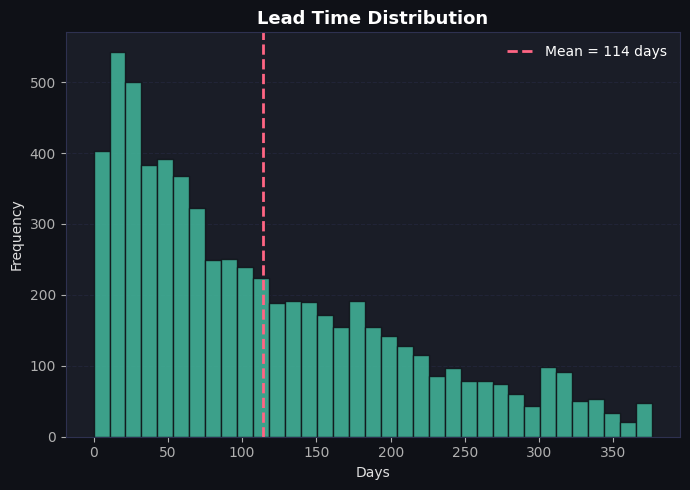

In [ ]:
fig, ax7 = plt.subplots(figsize=(7, 5), facecolor=BG)
ax7.set_facecolor(CARD)

ax7.hist(df['lead_time'], bins=35, color='#43b89c', edgecolor=BG, alpha=0.85)
ax7.axvline(df['lead_time'].mean(), color=ACCENT2, linewidth=2, linestyle='--',
            label=f'Mean = {df["lead_time"].mean():.0f} days')
ax7.legend(facecolor=CARD, edgecolor='none', labelcolor='white')
ax7.set_title('Lead Time Distribution', color='white', fontsize=13, fontweight='bold')
ax7.set_xlabel('Days'); ax7.set_ylabel('Frequency')
ax7.yaxis.grid(True, alpha=0.4); ax7.set_axisbelow(True)
plt.tight_layout()
plt.show()

Heatmap: Correlation Matrix

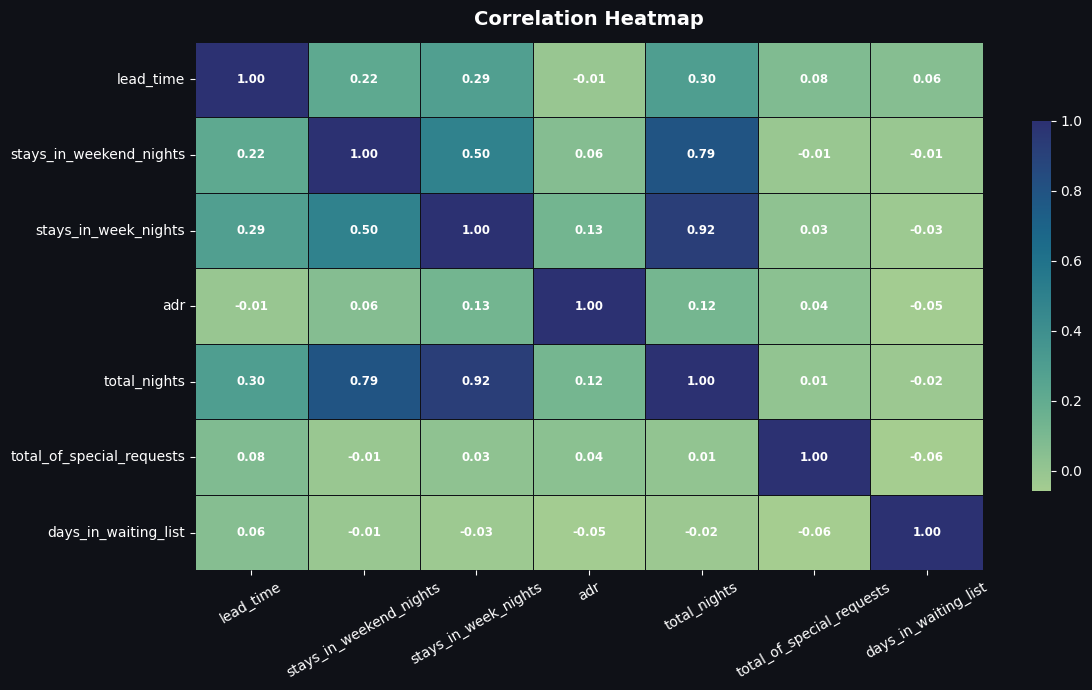

In [ ]:
fig, ax8 = plt.subplots(figsize=(12, 7), facecolor=BG)
ax8.set_facecolor(CARD)

if "total_nights" not in df.columns:
    df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

num_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'adr',
    'total_nights',
    'total_of_special_requests',
    'days_in_waiting_list'
]

valid_cols = [col for col in num_cols if col in df.columns and df[col].nunique() > 1]

corr = df[valid_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=0.7,
    linecolor=BG,
    ax=ax8,
    annot_kws={"size": 8.5, "color": "white", "fontweight": "bold"},
    cbar_kws={"shrink": 0.7}
)

ax8.set_title(
    'Correlation Heatmap',
    color='white',
    fontsize=14,
    fontweight='bold',
    pad=12
)

ax8.tick_params(axis='x', colors='white', rotation=30)
ax8.tick_params(axis='y', colors='white', rotation=0)

cbar = ax8.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.get_yticklabels(), color='white')

plt.tight_layout()
plt.show()

In [ ]:
df.to_excel('hotel_cleaned.xlsx', index=False)

from google.colab import files
files.download('hotel_cleaned.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pdf.close()
files.download(pdf_path)

print("PDF downloaded successfully ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF downloaded successfully ✅
